### Tools
Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:
1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
2. A function or coroutine to execute.

In [1]:
import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("Why do parrots talk ?")
response

AIMessage(content='<think>\nOkay, so I need to figure out why parrots talk. Let me start by recalling what I know about parrots. They\'re birds known for their ability to mimic human speech. But why do they do that? Maybe it\'s related to communication.\n\nI remember that some birds, like parrots and mynas, have a syrinx instead of a larynx, which allows them to produce a variety of sounds. The syrinx is the vocal organ in birds, so maybe their structure allows them to mimic human sounds better. But does that explain why they talk for communication or just how they can?\n\nIn the wild, parrots might use vocalizations to communicate with each other, maybe to signal location, warn of danger, or establish territory. So if they can mimic human speech, maybe they do it as a way to interact with humans. But is there a social aspect? Parrots are social animals, so talking might be a way to bond with their human companions, similar to how they interact with other parrots.\n\nAlso, some sources

In [2]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"


model_with_tools=model.bind_tools([get_weather])

In [3]:
response = model_with_tools.invoke("What's the weather like in Pune ?")
print(response)
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Pune. I need to use the get_weather function. The function requires a location parameter. Pune is a city in India, so I should specify that as the location. Let me check if there are any other parameters needed, but the tool only asks for location. So I\'ll call the function with "Pune" as the location. Make sure the JSON is correctly formatted with the name and arguments.\n', 'tool_calls': [{'id': 'hwk7b96ga', 'function': {'arguments': '{"location":"Pune"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 154, 'total_tokens': 270, 'completion_time': 0.189072477, 'completion_tokens_details': {'reasoning_tokens': 91}, 'prompt_time': 0.006141397, 'prompt_tokens_details': None, 'queue_time': 0.046159118, 'total_time': 0.195213874}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 

### Tool Execution Loops

In [4]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Pune ?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."

The weather in Pune is sunny. Have a great day! ☀️


In [5]:
messages

[{'role': 'user', 'content': "What's the weather in Boston?"},
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Boston. I need to use the get_weather function. Let me check the function parameters. The required parameter is location, which should be a string. Boston is the location here. So I\'ll call the function with location set to "Boston". Make sure the JSON is correctly formatted with the function name and arguments. No other functions are available, so this should be straightforward.\n', 'tool_calls': [{'id': '20cfda4p0', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 109, 'prompt_tokens': 153, 'total_tokens': 262, 'completion_time': 0.199966855, 'completion_tokens_details': {'reasoning_tokens': 85}, 'prompt_time': 0.006519155, 'prompt_tokens_details': None, 'queue_time': 0.055720395, 'total_time': 0.20648601}, 'mod

#### Agents

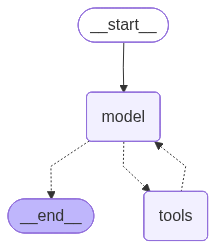

In [6]:
from langchain.agents import create_agent

from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[get_weather],
    system_prompt="You are a awesome "
)


agent


In [7]:
response = agent.invoke({"messages":[{"role":"user", "content":"What is the weather in Delhi ?"}]})
response

{'messages': [HumanMessage(content='What is the weather in Delhi ?', additional_kwargs={}, response_metadata={}, id='c2bb2947-a33c-40cb-8dd6-692217d4593a'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Delhi. Let me check the tools available. There\'s a function called get_weather that takes a location parameter. Since Delhi is the location specified, I need to call this function with "Delhi" as the argument. I\'ll make sure the parameters are correctly formatted in JSON and return the tool call as specified.\n', 'tool_calls': [{'id': '4td4tqx17', 'function': {'arguments': '{"location":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 158, 'total_tokens': 256, 'completion_time': 0.148409588, 'completion_tokens_details': {'reasoning_tokens': 73}, 'prompt_time': 0.006306115, 'prompt_tokens_details': None, 'queue_time': 0.04599756, 'total_tim

In [8]:
response['messages'][-1].content

'The weather in Delhi is sunny.'